In [1]:
# ============================================================
# LIBRARIAT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Lexo dataset-in e pastruar
df = pd.read_csv("../data/processed/laliga_master.csv")

print("Dimensionet:", df.shape)
print("OK!")

Dimensionet: (420, 33)
OK!


In [2]:
# ============================================================
# EKIPET STABILE VS FIGURANTET
# ============================================================

# Numëro sa sezone ka luajtur çdo ekip
sezoned_per_ekip = df.groupby("Squad")["sezoni"].count().reset_index()
sezoned_per_ekip.columns = ["ekipi", "sezoned"]
sezoned_per_ekip = sezoned_per_ekip.sort_values("sezoned", ascending=False)

print("=== PREZENCA NE LA LIGA (2004-2025) ===")
print(sezoned_per_ekip)

=== PREZENCA NE LA LIGA (2004-2025) ===
                  ekipi  sezoned
4       Atletico Madrid       21
5             Barcelona       21
3         Athletic Club       21
36             Valencia       21
33              Sevilla       21
29          Real Madrid       21
13               Getafe       20
38           Villarreal       20
12             Espanyol       19
28           Real Betis       18
31        Real Sociedad       18
25              Osasuna       17
7            Celta Vigo       15
23             Mallorca       14
21              Levante       14
22               Malaga       12
9   Deportivo La Coruna       12
16              Granada       10
27       Rayo Vallecano       10
37           Valladolid       10
0                Alaves        9
26     Racing Santander        8
40             Zaragoza        8
2               Almeria        8
10                Eibar        7
34       Sporting Gijon        6
20              Leganes        5
6                 Cadiz        5
11 

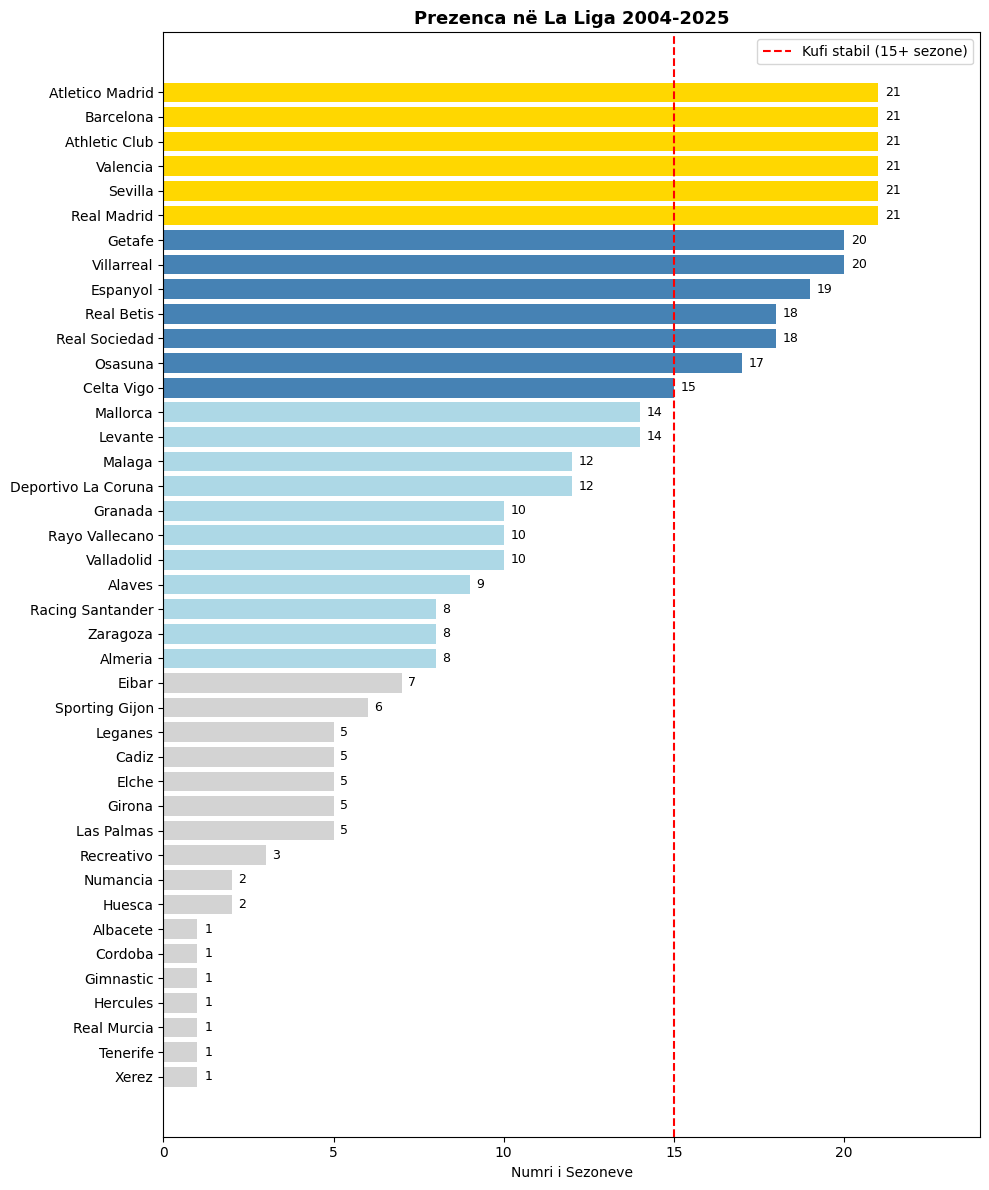

Grafiku u ruajt!


In [3]:
# ============================================================
# GRAFIK - PREZENCA NE LA LIGA
# ============================================================

fig, ax = plt.subplots(figsize=(10, 12))

# Ngjyra sipas prezencës
ngjyrat = []
for sez in sezoned_per_ekip["sezoned"]:
    if sez == 21:
        ngjyrat.append("gold")
    elif sez >= 15:
        ngjyrat.append("steelblue")
    elif sez >= 8:
        ngjyrat.append("lightblue")
    else:
        ngjyrat.append("lightgray")

bars = ax.barh(sezoned_per_ekip["ekipi"], sezoned_per_ekip["sezoned"], color=ngjyrat)

# Shto vlerat
for bar, val in zip(bars, sezoned_per_ekip["sezoned"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

# Vija e ndarjes — stabile vs figurant
ax.axvline(x=15, color="red", linestyle="--", linewidth=1.5, label="Kufi stabil (15+ sezone)")

ax.set_xlabel("Numri i Sezoneve")
ax.set_title("Prezenca në La Liga 2004-2025", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.legend()
ax.set_xlim(0, 24)

plt.tight_layout()
plt.savefig("../outputs/figures/07_prezenca.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

In [4]:
# ============================================================
# PËRCAKTO GJENDJET PER CԴDO EKIP NE ÇDO SEZON
# ============================================================

def percakto_gjendje(rank):
    if rank == 1:
        return "Kampion"
    elif rank <= 4:
        return "Top4"
    elif rank <= 10:
        return "MidTable"
    else:
        return "Fundtabele"

# Llogarit renditjen për çdo ekip në çdo sezon
df["rank"] = df.groupby("sezoni")["Pts"].rank(ascending=False, method="min").astype(int)

# Shto kolonën e gjendjes
df["gjendje"] = df["rank"].apply(percakto_gjendje)

# Kontrollo rezultatin
print(df[["Squad", "sezoni", "Pts", "rank", "gjendje"]].head(10))

                 Squad     sezoni  Pts  rank   gjendje
0            Barcelona  2004-2005   84     1   Kampion
1          Real Madrid  2004-2005   80     2      Top4
2           Villarreal  2004-2005   65     3      Top4
3           Real Betis  2004-2005   62     4      Top4
4             Espanyol  2004-2005   61     5  MidTable
5              Sevilla  2004-2005   60     6  MidTable
6             Valencia  2004-2005   58     7  MidTable
7        Athletic Club  2004-2005   51     8  MidTable
8  Deportivo La Coruna  2004-2005   51     8  MidTable
9               Malaga  2004-2005   51     8  MidTable


In [5]:
# ============================================================
# MATRICA E TRANZICIONIT
# ============================================================

# Rendit sipas ekipit dhe sezonit
df = df.sort_values(["Squad", "sezoni"]).reset_index(drop=True)

# Krijo kolonën e gjendjes së sezonit të ardhshëm
df["gjendje_ardhshme"] = df.groupby("Squad")["gjendje"].shift(-1)

# Hiq rreshtat ku ekipi nuk ka sezon të ardhshëm
tranzicionet = df.dropna(subset=["gjendje_ardhshme"])

# Numëro tranzicionet
matrica = pd.crosstab(
    tranzicionet["gjendje"],
    tranzicionet["gjendje_ardhshme"],
    normalize="index"
).round(3)

print("=== MATRICA E TRANZICIONIT ===")
print(matrica)

=== MATRICA E TRANZICIONIT ===
gjendje_ardhshme  Fundtabele  Kampion  MidTable   Top4
gjendje                                               
Fundtabele             0.674    0.000     0.297  0.029
Kampion                0.000    0.333     0.000  0.667
MidTable               0.459    0.000     0.418  0.123
Top4                   0.082    0.230     0.230  0.459


In [16]:
# ============================================================
# MATRICA E TRANZICIONIT PER EKIP SPECIFIK
# ============================================================

def matrica_per_ekip(ekipi, df):
    """
    Ndërton matricën e tranzicionit vetëm
    bazuar në historikun e atij ekipi
    """
    df_ekip = df[df["Squad"] == ekipi].sort_values("sezoni")
    df_ekip = df_ekip.copy()
    df_ekip["gjendje_ardhshme"] = df_ekip["gjendje"].shift(-1)
    df_ekip = df_ekip.dropna(subset=["gjendje_ardhshme"])

    # Nese ka te dhenat e mjaftueshme
    if len(df_ekip) < 3:
        return None

    matrica_ekip = pd.crosstab(
        df_ekip["gjendje"],
        df_ekip["gjendje_ardhshme"],
        normalize="index"
    )

    # Shto gjendjet qe mungojne me 0
    gjendjet = ["Kampion", "Top4", "MidTable", "Fundtabele"]
    for g in gjendjet:
        if g not in matrica_ekip.index:
            matrica_ekip.loc[g] = 0
        if g not in matrica_ekip.columns:
            matrica_ekip[g] = 0

    matrica_ekip = matrica_ekip.reindex(index=gjendjet, columns=gjendjet).fillna(0)

    # Rregulllo shumen
    matrica_ekip = matrica_ekip.div(matrica_ekip.sum(axis=1), axis=0).fillna(0)

    return matrica_ekip

# Testo per Real Madrid dhe Barcelona
mat_rm    = matrica_per_ekip("Real Madrid", df)
mat_barca = matrica_per_ekip("Barcelona", df)

print("=== REAL MADRID ===")
print(mat_rm.round(3))
print()
print("=== BARCELONA ===")
print(mat_barca.round(3))

=== REAL MADRID ===
gjendje_ardhshme  Kampion   Top4  MidTable  Fundtabele
gjendje                                               
Kampion             0.143  0.857       0.0         0.0
Top4                0.462  0.538       0.0         0.0
MidTable            0.000  0.000       0.0         0.0
Fundtabele          0.000  0.000       0.0         0.0

=== BARCELONA ===
gjendje_ardhshme  Kampion  Top4  MidTable  Fundtabele
gjendje                                              
Kampion              0.50  0.50       0.0         0.0
Top4                 0.75  0.25       0.0         0.0
MidTable             0.00  0.00       0.0         0.0
Fundtabele           0.00  0.00       0.0         0.0


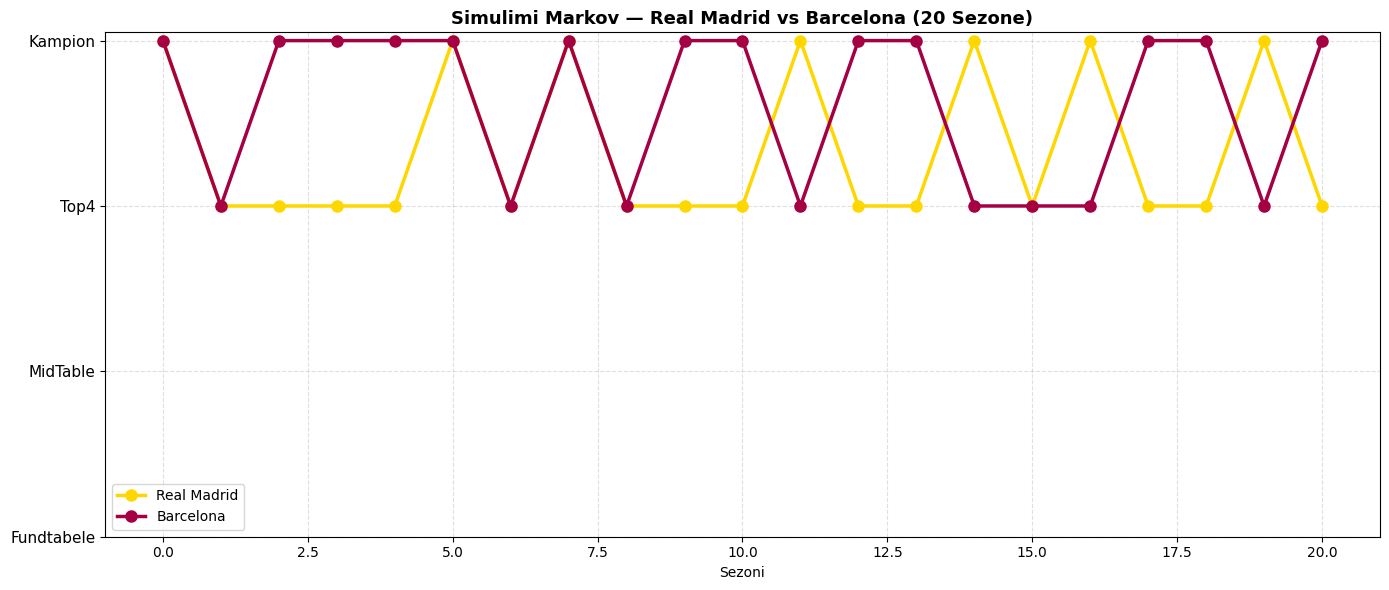

In [18]:
# ============================================================
# SIMULIMI ME MATRICAT SPECIFIKE
# ============================================================

np.random.seed(42)

sim_rm    = simulim_markov("Kampion", mat_rm,    sezone=20)
sim_barca = simulim_markov("Kampion", mat_barca, sezone=20)

# Vizualizimi
gjendje_numri = {
    "Kampion"   : 4,
    "Top4"      : 3,
    "MidTable"  : 2,
    "Fundtabele": 1
}

rm_numri    = [gjendje_numri[g] for g in sim_rm]
barca_numri = [gjendje_numri[g] for g in sim_barca]

fig, ax = plt.subplots(figsize=(14, 6))

sezone_x = list(range(21))

ax.plot(sezone_x, rm_numri,    color="gold",    linewidth=2.5,
        marker="o", markersize=8, label="Real Madrid")
ax.plot(sezone_x, barca_numri, color="#A50044", linewidth=2.5,
        marker="o", markersize=8, label="Barcelona")

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["Fundtabele", "MidTable", "Top4", "Kampion"], fontsize=11)
ax.set_xlabel("Sezoni")
ax.set_title("Simulimi Markov — Real Madrid vs Barcelona (20 Sezone)",
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/figures/09_simulimi_markov.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# MONTE CARLO - I SHPEJTE ME NUMPY
# ============================================================

N_SIMULIME = 10000
gjendjet   = ["Kampion", "Top4", "MidTable", "Fundtabele"]

# Gjendje fillestare per cdo ekip (e fundit historike)
gjendje_aktuale = {}
for ekip in ekipet_kryesore:
    g = df[df["Squad"] == ekip].sort_values("sezoni").iloc[-1]["gjendje"]
    gjendje_aktuale[ekip] = gjendjet.index(g)

# Matricat si numpy arrays
matricat_np = {}
for ekip, mat in matricat.items():
    matricat_np[ekip] = mat.reindex(
        index=gjendjet, columns=gjendjet).fillna(0).values

# Simulimi i shpejte — te gjithe ekipet njeheresh
rezultatet = {ekip: 0 for ekip in matricat}

for _ in range(N_SIMULIME):
    kampionet_sim = []
    
    for ekip in matricat:
        g_idx = gjendje_aktuale[ekip]
        prob  = matricat_np[ekip][g_idx]
        prob  = prob / prob.sum()
        g_ardhshme = np.random.choice(len(gjendjet), p=prob)
        
        if gjendjet[g_ardhshme] == "Kampion":
            kampionet_sim.append(ekip)
    
    if kampionet_sim:
        fitues = np.random.choice(kampionet_sim)
        rezultatet[fitues] += 1

# Normalizo
total = sum(rezultatet.values())
prob_kampion = {ekip: rezultatet[ekip] / total 
                for ekip in rezultatet}
prob_kampion = dict(sorted(prob_kampion.items(), 
                           key=lambda x: x[1], reverse=True))

print("=== PROBABILITETI I KAMPIONATIT ===")
for ekip, prob in prob_kampion.items():
    print(f"{ekip:25} {prob:.3f} ({prob*100:.1f}%)")


=== PROBABILITETI I KAMPIONATIT ===
Barcelona                 0.462 (46.2%)
Real Madrid               0.406 (40.6%)
Atletico Madrid           0.132 (13.2%)
Sevilla                   0.000 (0.0%)
Villarreal                0.000 (0.0%)
Valencia                  0.000 (0.0%)
Athletic Club             0.000 (0.0%)
Real Sociedad             0.000 (0.0%)

Total: 1.000


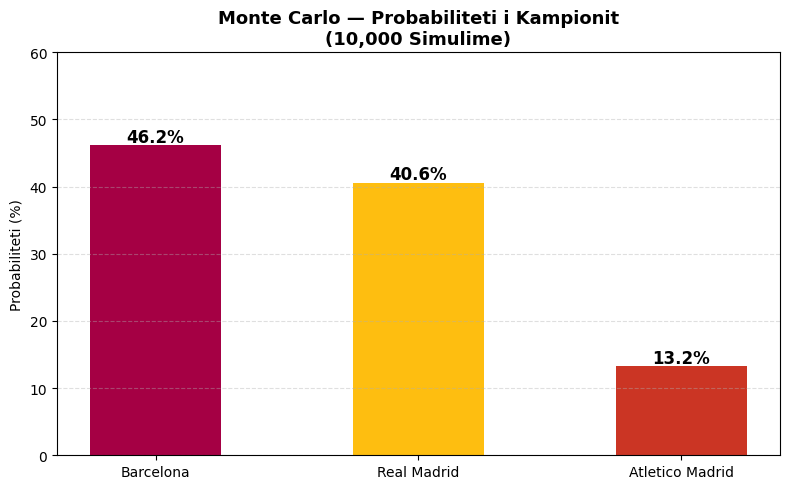

Grafiku u ruajt!


In [22]:
# ============================================================
# GRAFIKU - MONTE CARLO
# ============================================================

# Filtro vetem ekipet me prob > 0
prob_plot = {e: p for e, p in prob_kampion.items() if p > 0}

fig, ax = plt.subplots(figsize=(8, 5))

ngjyrat = ["#A50044", "#FEBE10", "#CB3524"]

bars = ax.bar(prob_plot.keys(), 
              [p * 100 for p in prob_plot.values()],
              color=ngjyrat, width=0.5)

# Shto vlerat mbi shtyllat
for bar, val in zip(bars, prob_plot.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val*100:.1f}%",
            ha="center", fontsize=12, fontweight="bold")

ax.set_ylabel("Probabiliteti (%)")
ax.set_title("Monte Carlo — Probabiliteti i Kampionit\n(10,000 Simulime)",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 60)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/figures/10_monte_carlo.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

In [24]:
# ============================================================
# BINOMIALI — P(X = k kampionate në n sezone)
# ============================================================
from scipy.stats import binom

# Probabiliteti historik i fitores per ekip
# P(kampion) = titujt / sezoned_totale
n_sezone = 21  # sezone totale

p_barcelona = 12 / n_sezone   # 12 tituj nga 21
p_realmadrid = 7 / n_sezone   # 7 tituj nga 21
p_atletico   = 2 / n_sezone   # 2 tituj nga 21

print("=== PROBABILITETET HISTORIKE ===")
print(f"Barcelona      : {p_barcelona:.3f} ({p_barcelona*100:.1f}%)")
print(f"Real Madrid    : {p_realmadrid:.3f} ({p_realmadrid*100:.1f}%)")
print(f"Atletico Madrid: {p_atletico:.3f} ({p_atletico*100:.1f}%)")

# P(X = k) — probabiliteti per k tituj ne 10 sezone te ardhshme
n = 10  # sezone te ardhshme
k_vlerat = list(range(0, 11))  # 0 deri 10 tituj

prob_binom_barca = [binom.pmf(k, n, p_barcelona) for k in k_vlerat]
prob_binom_rm    = [binom.pmf(k, n, p_realmadrid) for k in k_vlerat]
prob_binom_atl   = [binom.pmf(k, n, p_atletico)   for k in k_vlerat]

print("\n=== P(X=k tituj) ne 10 sezone ===")
print(f"{'k':>3} {'Barcelona':>12} {'Real Madrid':>12} {'Atletico':>12}")
for k in k_vlerat:
    print(f"{k:>3} {prob_binom_barca[k]:>12.4f} {prob_binom_rm[k]:>12.4f} {prob_binom_atl[k]:>12.4f}")

=== PROBABILITETET HISTORIKE ===
Barcelona      : 0.571 (57.1%)
Real Madrid    : 0.333 (33.3%)
Atletico Madrid: 0.095 (9.5%)

=== P(X=k tituj) ne 10 sezone ===
  k    Barcelona  Real Madrid     Atletico
  0       0.0002       0.0173       0.3676
  1       0.0028       0.0867       0.3869
  2       0.0167       0.1951       0.1833
  3       0.0595       0.2601       0.0514
  4       0.1387       0.2276       0.0095
  5       0.2220       0.1366       0.0012
  6       0.2467       0.0569       0.0001
  7       0.1879       0.0163       0.0000
  8       0.0940       0.0030       0.0000
  9       0.0278       0.0003       0.0000
 10       0.0037       0.0000       0.0000


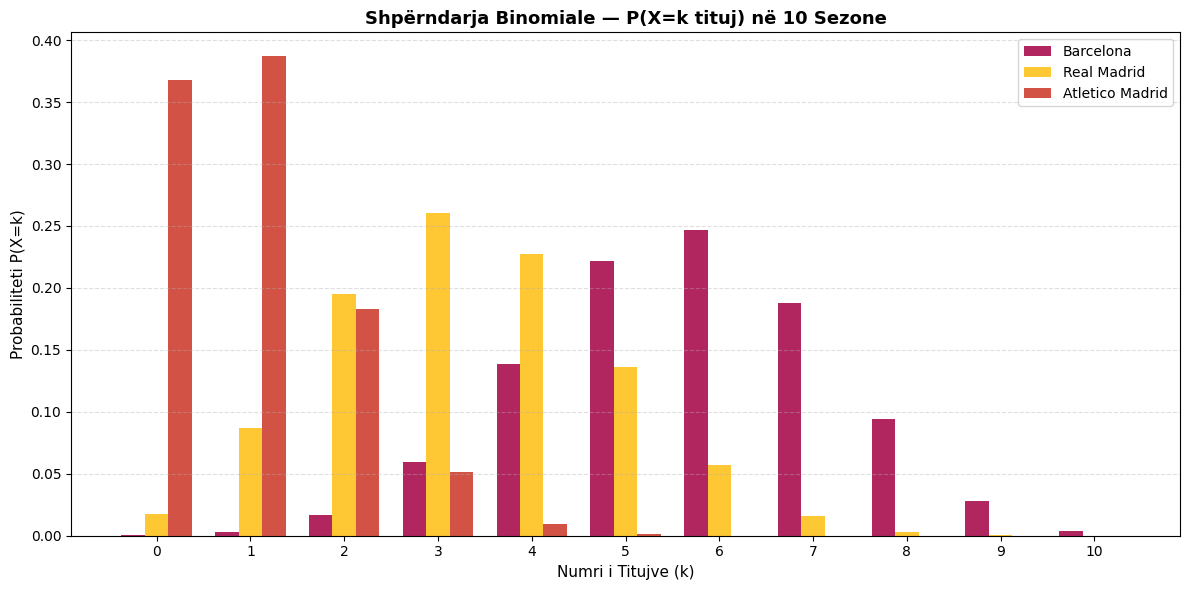

Grafiku u ruajt!


In [25]:
# ============================================================
# GRAFIKU - BINOMIALI
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

x      = np.array(k_vlerat)
width  = 0.25

ax.bar(x - width, prob_binom_barca, width, 
       color="#A50044", label="Barcelona",       alpha=0.85)
ax.bar(x,          prob_binom_rm,   width, 
       color="#FEBE10", label="Real Madrid",     alpha=0.85)
ax.bar(x + width,  prob_binom_atl,  width, 
       color="#CB3524", label="Atletico Madrid", alpha=0.85)

ax.set_xlabel("Numri i Titujve (k)", fontsize=11)
ax.set_ylabel("Probabiliteti P(X=k)", fontsize=11)
ax.set_title("Shpërndarja Binomiale — P(X=k tituj) në 10 Sezone",
             fontsize=13, fontweight="bold")
ax.set_xticks(k_vlerat)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/figures/11_binomiali.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

In [26]:
# ============================================================
# MATRICA E KOVARIANCËS
# ============================================================

# Variablat për simulim — vetëm ekipet kryesore me 9+ sezone
ekipet_stabile = sezoned_per_ekip[
    sezoned_per_ekip["sezoned"] >= 15
]["ekipi"].tolist()

# Kolonat për kovariancë
kolonat_kov = ["Pts", "GF", "GA", "GD", "Sh", "SoT", "Save%", "Poss"]

# Filtro vetëm ekipet stabile dhe kolonat që ekzistojnë
df_kov = df[df["Squad"].isin(ekipet_stabile)][["Squad"] + kolonat_kov].dropna()

print("Ekipet stabile:", df_kov["Squad"].unique().tolist())
print("Dimensionet:", df_kov.shape)
print()

# Matrica e kovariancës
kov_matrix = df_kov[kolonat_kov].cov().round(2)
print("=== MATRICA E KOVARIANCËS ===")
print(kov_matrix)

Ekipet stabile: ['Athletic Club', 'Atletico Madrid', 'Barcelona', 'Celta Vigo', 'Espanyol', 'Getafe', 'Osasuna', 'Real Betis', 'Real Madrid', 'Real Sociedad', 'Sevilla', 'Valencia', 'Villarreal']
Dimensionet: (124, 9)

=== MATRICA E KOVARIANCËS ===
          Pts       GF      GA       GD       Sh      SoT  Save%    Poss
Pts    268.77   242.38 -144.38   386.76   881.45   488.97  50.07   69.58
GF     242.38   313.70  -82.04   395.73  1133.23   638.74  27.11   82.15
GA    -144.38   -82.04  144.73  -226.77  -302.81  -148.86 -52.13  -24.37
GD     386.76   395.73 -226.77   622.50  1436.04   787.60  79.24  106.52
Sh     881.45  1133.23 -302.81  1436.04  6030.22  2757.94  90.02  343.63
SoT    488.97   638.74 -148.86   787.60  2757.94  1536.98  46.35  179.94
Save%   50.07    27.11  -52.13    79.24    90.02    46.35  28.05    4.62
Poss    69.58    82.15  -24.37   106.52   343.63   179.94   4.62   41.26


In [28]:
# ============================================================
# MONTE CARLO ME MATRICË KOVARIANCË — I OPTIMIZUAR
# ============================================================

N_SIMULIME = 10000

# Llogarit mesataret dhe kovariancen JASHTE loop-it
mesataret = {}
kovariancet = {}

for ekip in ekipet_stabile:
    df_ekip = df_kov[df_kov["Squad"] == ekip][kolonat_kov]
    if len(df_ekip) >= 3:
        mesataret[ekip]   = df_ekip.mean().values
        kovariancet[ekip] = df_ekip.cov().values

# Gjenero te gjitha simulimet njeheresh per cdo ekip
simulimet = {}
for ekip in mesataret:
    simulimet[ekip] = np.random.multivariate_normal(
        mesataret[ekip],
        kovariancet[ekip],
        size=N_SIMULIME
    )[:, 0]  # Merr vetem Pts (kolona e pare)

# Gjej kampionin per cdo simulim
df_sim = pd.DataFrame(simulimet)
kampionet_sim = df_sim.idxmax(axis=1)

# Probabilitetet
prob_mc = kampionet_sim.value_counts(normalize=True).sort_values(ascending=False)

print("=== MONTE CARLO — PROBABILITETI I KAMPIONIT ===")
for ekip, prob in prob_mc.items():
    print(f"{ekip:25} {prob:.3f} ({prob*100:.1f}%)")

=== MONTE CARLO — PROBABILITETI I KAMPIONIT ===
Barcelona                 0.502 (50.2%)
Real Madrid               0.401 (40.1%)
Atletico Madrid           0.078 (7.8%)
Sevilla                   0.016 (1.6%)
Villarreal                0.001 (0.1%)
Athletic Club             0.001 (0.1%)
Real Sociedad             0.000 (0.0%)
Real Betis                0.000 (0.0%)


C:\Users\user\AppData\Local\Temp\ipykernel_25228\598087556.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(prob_plot.index, rotation=20, ha="right")


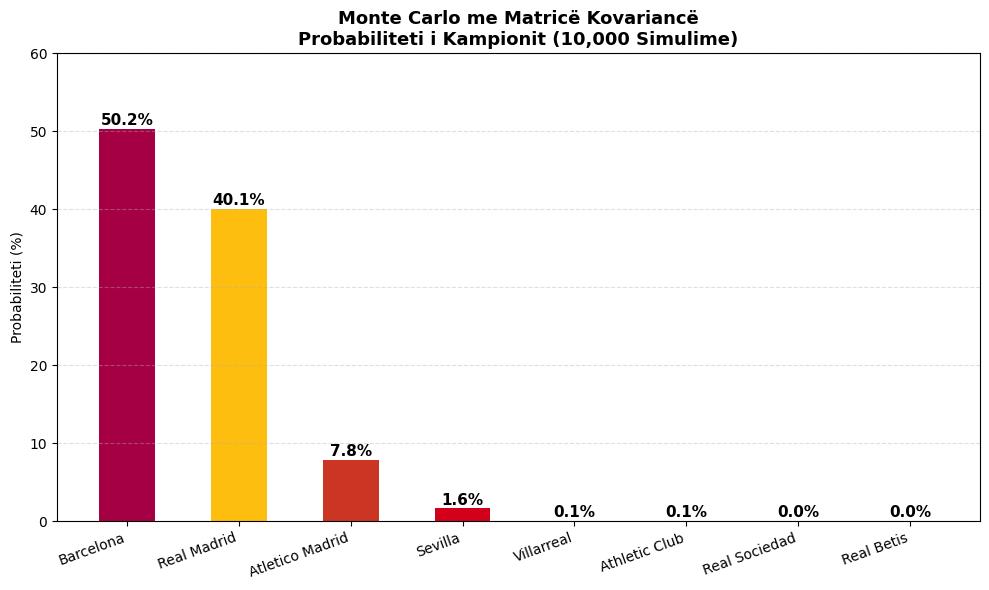

Grafiku u ruajt!


In [29]:
# ============================================================
# GRAFIKU - MONTE CARLO ME KOVARIANCË
# ============================================================

# Filtro ekipet me prob > 0
prob_plot = prob_mc[prob_mc > 0]

fig, ax = plt.subplots(figsize=(10, 6))

ngjyrat = {
    "Barcelona"      : "#A50044",
    "Real Madrid"    : "#FEBE10",
    "Atletico Madrid": "#CB3524",
    "Sevilla"        : "#D2001A",
    "Villarreal"     : "#FFD700",
    "Athletic Club"  : "#EE7203",
    "Real Sociedad"  : "#0067B1",
    "Real Betis"     : "#00954C"
}

barras_ngjyrat = [ngjyrat.get(e, "steelblue") for e in prob_plot.index]

bars = ax.bar(prob_plot.index,
              prob_plot.values * 100,
              color=barras_ngjyrat, width=0.5)

# Shto vlerat mbi shtyllat
for bar, val in zip(bars, prob_plot.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val*100:.1f}%",
            ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Probabiliteti (%)")
ax.set_title("Monte Carlo me Matricë Kovariancë\nProbabiliteti i Kampionit (10,000 Simulime)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(prob_plot.index, rotation=20, ha="right")
ax.set_ylim(0, 60)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/figures/12_monte_carlo_kov.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")